In [4]:
"""
fetch_sas_playoff_data.py
=========================
Fetches real box score data for all 20 San Antonio Spurs 2026 playoff games
from the SportRadar NBA API and writes a CSV ready for the Bayesian HLM.

Requirements:
    pip install requests

Usage:
    Set your API key below (or as env var SPORTRADAR_API_KEY), then:
    python fetch_sas_playoff_data.py

SportRadar NBA API docs:
    https://developer.sportradar.com/docs/read/basketball/NBA_v8
"""

import os
import time
import requests
import csv
from datetime import datetime, timezone

# ─────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────
API_KEY   = os.environ.get("SPORTRADAR_API_KEY", "YOUR API KEY")
BASE_URL  = "https://api.sportradar.com/nba/trial/v8/en/games/{game_id}/summary.json"
SAS_ALIAS = {"SA", "SAS", "San Antonio", "San Antonio Spurs"}

# SportRadar rate limit: 1 request/second on trial, 10/second on paid
REQUEST_DELAY = 1.1   # seconds between calls; increase to 6.0 if on trial tier
MAX_RETRIES   = 3     # retry attempts on 429 rate limit response
OUTPUT_FILE = "spurs_2026_playoffs_all20.csv"

# ─────────────────────────────────────────────────────────
# ALL 20 GAME IDs  (from SportRadar scores API)
# Metadata kept here so the CSV is self-documenting
# ─────────────────────────────────────────────────────────
GAMES = [
    # ── NBA Finals vs New York Knicks ────────────────────
    dict(game_id="e4ee37b5-470a-4ae5-8907-afd2e5aae49f",
         series="NBA Finals", round=4, opponent="NYK",
         location="Home", sas_score=95,  opp_score=105, group=0),
    dict(game_id="46314888-2206-409e-a4e9-0dcd89cf0b5a",
         series="NBA Finals", round=4, opponent="NYK",
         location="Home", sas_score=104, opp_score=105, group=0),

    # ── WCF vs Oklahoma City Thunder ─────────────────────
    dict(game_id="d330a300-65fa-44df-8f8a-dc873736f09e",
         series="WCF", round=3, opponent="OKC",
         location="Away", sas_score=122, opp_score=115, group=1),
    dict(game_id="2b46dfc3-486c-497e-ad6e-5f03cd7d174b",
         series="WCF", round=3, opponent="OKC",
         location="Away", sas_score=113, opp_score=122, group=1),
    dict(game_id="705f7114-c609-4bef-a88b-868ed6f2720e",
         series="WCF", round=3, opponent="OKC",
         location="Home", sas_score=108, opp_score=123, group=1),
    dict(game_id="7bccbef2-8e95-483d-897a-7f7094493b39",
         series="WCF", round=3, opponent="OKC",
         location="Home", sas_score=103, opp_score=82,  group=1),
    dict(game_id="3bca7139-e255-412d-aaa8-c2fb23a965f6",
         series="WCF", round=3, opponent="OKC",
         location="Away", sas_score=114, opp_score=127, group=1),
    dict(game_id="073e8c82-f8d0-4ca4-a94f-cc9d58cd7832",
         series="WCF", round=3, opponent="OKC",
         location="Home", sas_score=118, opp_score=91,  group=1),
    dict(game_id="da5d69c1-4b9f-428e-a515-c8102aa62199",
         series="WCF", round=3, opponent="OKC",
         location="Away", sas_score=111, opp_score=103, group=1),

    # ── R2 vs Minnesota Timberwolves ─────────────────────
    dict(game_id="92b3b712-c809-4284-abd8-893c3065642a",
         series="R2", round=2, opponent="MIN",
         location="Home", sas_score=102, opp_score=104, group=1),
    dict(game_id="726bd6c3-dab6-4fc3-ab66-a25cb9d2d100",
         series="R2", round=2, opponent="MIN",
         location="Home", sas_score=133, opp_score=95,  group=1),
    dict(game_id="8a9ba7d2-2072-4cb6-93f3-087e975c3167",
         series="R2", round=2, opponent="MIN",
         location="Away", sas_score=115, opp_score=108, group=1),
    dict(game_id="7b29ddc3-fa9d-4845-9549-d2d4501f8d36",
         series="R2", round=2, opponent="MIN",
         location="Away", sas_score=109, opp_score=114, group=1),
    dict(game_id="da78daaa-92e6-4616-a901-67db7fc36ade",
         series="R2", round=2, opponent="MIN",
         location="Home", sas_score=126, opp_score=97,  group=1),
    dict(game_id="f616f274-a28f-4e49-9b1c-96c932ce5c6a",
         series="R2", round=2, opponent="MIN",
         location="Away", sas_score=139, opp_score=109, group=1),

    # ── R1 vs Portland Trail Blazers ─────────────────────
    dict(game_id="c09aa35b-bbaa-4bf7-925a-f6b89c6db224",
         series="R1", round=1, opponent="POR",
         location="Home", sas_score=111, opp_score=98,  group=1),
    dict(game_id="f044eb3a-be46-4cf7-b984-01103b729749",
         series="R1", round=1, opponent="POR",
         location="Home", sas_score=103, opp_score=106, group=1),
    dict(game_id="74d28f20-c249-499c-9d90-0b04800670ca",
         series="R1", round=1, opponent="POR",
         location="Away", sas_score=120, opp_score=108, group=1),
    dict(game_id="2284ca46-65f3-4a46-82bc-82f99150eaab",
         series="R1", round=1, opponent="POR",
         location="Away", sas_score=114, opp_score=93,  group=1),
    dict(game_id="d5a3ba6f-5f15-4de0-a31b-b692320fb9da",
         series="R1", round=1, opponent="POR",
         location="Home", sas_score=114, opp_score=95,  group=1),
]

# ─────────────────────────────────────────────────────────
# PARSER — extract SAS team stats from boxscore JSON
# ─────────────────────────────────────────────────────────
def is_sas(team: dict) -> bool:
    """Return True if this team dict is the Spurs."""
    alias = team.get("alias", "")
    name  = team.get("name", "")
    market= team.get("market", "")
    return alias in SAS_ALIAS or "San Antonio" in market or "Spurs" in name

def safe(d: dict, key: str, default=0.0):
    """
    Safe single-key dict lookup. Returns 0.0 by default (not None)
    so csv.DictWriter never writes empty strings that become NaN
    in pandas and crash PyMC/Stan samplers.
    """
    if not isinstance(d, dict):
        return default
    val = d.get(key)
    return float(val) if val is not None else default

def parse_boxscore(data: dict, meta: dict) -> dict | None:
    """
    Extract SAS team-level statistics from a SportRadar boxscore response.
    Returns a flat dict ready for the CSV row, or None if SAS not found.
    """
    # SportRadar boxscore has a 'home' and 'away' team block
    home = data.get("home", {})
    away = data.get("away", {})

    sas_team  = None
    opp_team  = None
    sas_venue = None

    if is_sas(home):
        sas_team, opp_team, sas_venue = home, away, "Home"
    elif is_sas(away):
        sas_team, opp_team, sas_venue = away, home, "Away"
    else:
        print(f"  ✗ Could not identify SAS team in game {meta['game_id']}")
        return None

    # Prefer statistics block; fall back to totals
    st = sas_team.get("statistics", sas_team.get("totals", {}))

    # True shooting % computed from first principles — avoids relying on
    # SportRadar key name which varies across API versions
    sas_fga = safe(st, "field_goals_att")
    sas_fta = safe(st, "free_throws_att")
    ts_att  = sas_fga + 0.44 * sas_fta
    ts_pct  = round((meta["sas_score"] / (2 * ts_att)), 3) if ts_att > 0 else 0.0

    win = 1 if meta["sas_score"] > meta["opp_score"] else 0

    row = {
        "game_id":           meta["game_id"],
        "series":            meta["series"],
        "round":             meta["round"],
        "opponent":          meta["opponent"],
        "location":          sas_venue,          # use API-confirmed home/away
        "sas_score":         meta["sas_score"],
        "opp_score":         meta["opp_score"],
        "win":               win,
        "group":             meta["group"],       # 0=NYK Finals, 1=Other

        # Shooting
        "fg_made":           safe(st, "field_goals_made"),
        "fg_att":            sas_fga,
        "fg_pct":            safe(st, "field_goals_pct"),
        "three_made":        safe(st, "three_points_made"),
        "three_att":         safe(st, "three_points_att"),
        "three_pt_pct":      safe(st, "three_points_pct"),
        "ft_made":           safe(st, "free_throws_made"),
        "ft_att":            sas_fta,
        "ft_pct":            safe(st, "free_throws_pct"),

        # Rebounding
        "off_reb":           safe(st, "offensive_rebounds"),
        "def_reb":           safe(st, "defensive_rebounds"),
        "total_reb":         safe(st, "rebounds"),

        # Other counting stats
        "assists":           safe(st, "assists"),
        "steals":            safe(st, "steals"),
        "blocks":            safe(st, "blocked_shots"),
        "turnovers":         safe(st, "turnovers"),
        "fouls":             safe(st, "personal_fouls"),
        "points":            safe(st, "points"),

        # Advanced / situational
        "points_in_paint":   safe(st, "points_in_paint"),
        "fast_break_pts":    safe(st, "fast_break_pts"),
        "second_chance_pts": safe(st, "second_chance_pts"),
        "eff_fg_pct":        safe(st, "effective_fg_pct"),
        "true_shooting_pct": ts_pct,
        "largest_lead":      safe(st, "largest_lead"),

        "data_source": "SportRadar API",
        "fetched_at":  datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
    }
    return row

# ─────────────────────────────────────────────────────────
# MAIN FETCH LOOP
# ─────────────────────────────────────────────────────────
def fetch_all() -> list[dict]:
    rows = []
    failed = []

    print(f"Fetching {len(GAMES)} games from SportRadar…\n")

    for i, meta in enumerate(GAMES, 1):
        gid = meta["game_id"]
        url = BASE_URL.format(game_id=gid)
        params = {"api_key": API_KEY}

        print(f"[{i:02d}/{len(GAMES)}] {meta['series']} vs {meta['opponent']} "
              f"({meta['sas_score']}-{meta['opp_score']})  …", end=" ", flush=True)

        # Retry loop with exponential backoff on 429
        success = False
        for attempt in range(MAX_RETRIES):
            try:
                r = requests.get(url, params=params, timeout=15)

                if r.status_code == 429:
                    wait = 2 ** attempt
                    print(f"[429] rate limited — waiting {wait}s…", end=" ", flush=True)
                    time.sleep(wait)
                    continue

                r.raise_for_status()
                data = r.json()
                row  = parse_boxscore(data, meta)

                if row:
                    rows.append(row)
                    win_str = "W" if row["win"] else "L"
                    print(f"✓  ({win_str}) FG%={row['fg_pct']}  "
                          f"REB={row['total_reb']}  AST={row['assists']}  "
                          f"TO={row['turnovers']}")
                else:
                    failed.append(gid)
                    print("✗  parse failed")

                success = True
                break

            except requests.HTTPError as e:
                print(f"✗  HTTP {r.status_code}: {e}")
                break
            except Exception as e:
                print(f"✗  {e}")
                break

        if not success and gid not in failed:
            failed.append(gid)

        if i < len(GAMES):
            time.sleep(REQUEST_DELAY)

    if failed:
        print(f"\n⚠  Failed game IDs ({len(failed)}):")
        for gid in failed:
            print(f"   {gid}")

    return rows

# ─────────────────────────────────────────────────────────
# WRITE CSV
# ─────────────────────────────────────────────────────────
def write_csv(rows: list[dict], path: str):
    if not rows:
        print("No rows to write.")
        return

    fieldnames = list(rows[0].keys())
    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print(f"\n✓  Wrote {len(rows)} rows → {path}")

    # Quick sanity summary
    wins   = sum(r["win"] for r in rows)
    losses = len(rows) - wins
    nyks   = [r for r in rows if r["group"] == 0]
    other  = [r for r in rows if r["group"] == 1]
    print(f"   Overall: {wins}W – {losses}L")
    print(f"   NYK Finals group:  {len(nyks)} games")
    print(f"   Other playoffs group: {len(other)} games")

# ─────────────────────────────────────────────────────────
# ENTRY POINT
# ─────────────────────────────────────────────────────────
if __name__ == "__main__":
    if API_KEY == "YOUR_API_KEY_HERE":
        print("ERROR: Set your SportRadar API key in the API_KEY variable "
              "or via the SPORTRADAR_API_KEY environment variable.")
        raise SystemExit(1)

    rows = fetch_all()
    write_csv(rows, OUTPUT_FILE)

    print(f"\nNext step: pass {OUTPUT_FILE} into spurs_bayesian_model.py")
    print("Replace the manual 'rows = [...]' list with:")
    print("  import pandas as pd")
    print(f"  df = pd.read_csv('{OUTPUT_FILE}')")


Fetching 20 games from SportRadar…

[01/20] NBA Finals vs NYK (95-105)  … ✓  (L) FG%=36.0  REB=0.0  AST=16.0  TO=0.0
[02/20] NBA Finals vs NYK (104-105)  … ✓  (L) FG%=47.4  REB=0.0  AST=22.0  TO=0.0
[03/20] WCF vs OKC (122-115)  … ✓  (W) FG%=42.7  REB=0.0  AST=25.0  TO=0.0
[04/20] WCF vs OKC (113-122)  … ✓  (L) FG%=48.8  REB=0.0  AST=22.0  TO=0.0
[05/20] WCF vs OKC (108-123)  … ✓  (L) FG%=42.5  REB=0.0  AST=26.0  TO=0.0
[06/20] WCF vs OKC (103-82)  … ✓  (W) FG%=38.9  REB=0.0  AST=25.0  TO=0.0
[07/20] WCF vs OKC (114-127)  … ✓  (L) FG%=40.2  REB=0.0  AST=25.0  TO=0.0
[08/20] WCF vs OKC (118-91)  … ✓  (W) FG%=46.6  REB=0.0  AST=30.0  TO=0.0
[09/20] WCF vs OKC (111-103)  … ✓  (W) FG%=45.5  REB=0.0  AST=21.0  TO=0.0
[10/20] R2 vs MIN (102-104)  … ✓  (L) FG%=44.8  REB=0.0  AST=24.0  TO=0.0
[11/20] R2 vs MIN (133-95)  … ✓  (W) FG%=50.0  REB=0.0  AST=29.0  TO=0.0
[12/20] R2 vs MIN (115-108)  … ✓  (W) FG%=45.9  REB=0.0  AST=26.0  TO=0.0
[13/20] R2 vs MIN (109-114)  … ✓  (L) FG%=47.7  REB=0.0  

In [2]:
import os, json, requests

API_KEY = os.environ.get("SPORTRADAR_API_KEY", "YOUR API KEY")
url = "https://api.sportradar.com/nba/trial/v8/en/games/e4ee37b5-470a-4ae5-8907-afd2e5aae49f/boxscore.json"

r = requests.get(url, params={"api_key": API_KEY}, timeout=15)
data = r.json()

# Print top-level keys
print("Top-level keys:", list(data.keys()))

# Find the team blocks and print their keys
for key in ["home", "away"]:
    team = data.get(key, {})
    print(f"\n{key} team keys:", list(team.keys()))
    for subkey in ["statistics", "totals", "scoring"]:
        if subkey in team:
            print(f"  {subkey} keys:", list(team[subkey].keys())[:10])

Top-level keys: ['id', 'title', 'status', 'coverage', 'scheduled', 'duration', 'attendance', 'lead_changes', 'times_tied', 'clock', 'quarter', 'track_on_court', 'reference', 'entry_mode', 'sr_id', 'clock_decimal', 'broadcasts', 'time_zones', 'season', 'home', 'away']

home team keys: ['name', 'alias', 'market', 'id', 'points', 'bonus', 'sr_id', 'remaining_timeouts', 'reference', 'record', 'scoring', 'leaders']


AttributeError: 'list' object has no attribute 'keys'

In [6]:
import os, requests


API_KEY = os.environ.get("SPORTRADAR_API_KEY", "YOUR API KEY")
# Note the change to summary.json here!
url = "https://api.sportradar.com/nba/trial/v8/en/games/e4ee37b5-470a-4ae5-8907-afd2e5aae49f/summary.json"

r = requests.get(url, params={"api_key": API_KEY}, timeout=15)
data = r.json()

home_team = data.get("home", {})
print("Home team keys:", list(home_team.keys()))

if "statistics" in home_team:
    print("\nSUCCESS! Found the statistics block.")
    print("Stats available:", list(home_team["statistics"].keys())[:15])
else:
    print("\nStill no statistics block found.")

Home team keys: ['name', 'alias', 'market', 'id', 'points', 'bonus', 'sr_id', 'remaining_timeouts', 'reference', 'record', 'scoring', 'statistics', 'coaches', 'players']

SUCCESS! Found the statistics block.
Stats available: ['minutes', 'field_goals_made', 'field_goals_att', 'field_goals_pct', 'three_points_made', 'three_points_att', 'three_points_pct', 'two_points_made', 'two_points_att', 'two_points_pct', 'blocked_att', 'free_throws_made', 'free_throws_att', 'free_throws_pct', 'offensive_rebounds']


In [7]:
"""
fetch_sas_playoff_data.py
=========================
Fetches real box score data for all 20 San Antonio Spurs 2026 playoff games
from the SportRadar NBA API and writes a CSV ready for the Bayesian HLM.
"""

import os
import time
import requests
import csv
from datetime import datetime, timezone

# ─────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────
API_KEY   = os.environ.get("SPORTRADAR_API_KEY", "eOzhfQHNDRXDyrf52Oe502Uwb86Sd3A5tNtgPre4")
BASE_URL  = "https://api.sportradar.com/nba/trial/v8/en/games/{game_id}/summary.json"
SAS_ALIAS = {"SA", "SAS", "San Antonio", "San Antonio Spurs"}

REQUEST_DELAY = 1.2   
MAX_RETRIES   = 3     
OUTPUT_FILE = "spurs_2026_playoffs_all20.csv"

# ─────────────────────────────────────────────────────────
# ALL 20 GAME IDs
# ─────────────────────────────────────────────────────────
GAMES = [
    dict(game_id="e4ee37b5-470a-4ae5-8907-afd2e5aae49f", series="NBA Finals", round=4, opponent="NYK", location="Home", sas_score=95,  opp_score=105, group=0),
    dict(game_id="46314888-2206-409e-a4e9-0dcd89cf0b5a", series="NBA Finals", round=4, opponent="NYK", location="Home", sas_score=104, opp_score=105, group=0),
    dict(game_id="d330a300-65fa-44df-8f8a-dc873736f09e", series="WCF", round=3, opponent="OKC", location="Away", sas_score=122, opp_score=115, group=1),
    dict(game_id="2b46dfc3-486c-497e-ad6e-5f03cd7d174b", series="WCF", round=3, opponent="OKC", location="Away", sas_score=113, opp_score=122, group=1),
    dict(game_id="705f7114-c609-4bef-a88b-868ed6f2720e", series="WCF", round=3, opponent="OKC", location="Home", sas_score=108, opp_score=123, group=1),
    dict(game_id="7bccbef2-8e95-483d-897a-7f7094493b39", series="WCF", round=3, opponent="OKC", location="Home", sas_score=103, opp_score=82,  group=1),
    dict(game_id="3bca7139-e255-412d-aaa8-c2fb23a965f6", series="WCF", round=3, opponent="OKC", location="Away", sas_score=114, opp_score=127, group=1),
    dict(game_id="073e8c82-f8d0-4ca4-a94f-cc9d58cd7832", series="WCF", round=3, opponent="OKC", location="Home", sas_score=118, opp_score=91,  group=1),
    dict(game_id="da5d69c1-4b9f-428e-a515-c8102aa62199", series="WCF", round=3, opponent="OKC", location="Away", sas_score=111, opp_score=103, group=1),
    dict(game_id="92b3b712-c809-4284-abd8-893c3065642a", series="R2", round=2, opponent="MIN", location="Home", sas_score=102, opp_score=104, group=1),
    dict(game_id="726bd6c3-dab6-4fc3-ab66-a25cb9d2d100", series="R2", round=2, opponent="MIN", location="Home", sas_score=133, opp_score=95,  group=1),
    dict(game_id="8a9ba7d2-2072-4cb6-93f3-087e975c3167", series="R2", round=2, opponent="MIN", location="Away", sas_score=115, opp_score=108, group=1),
    dict(game_id="7b29ddc3-fa9d-4845-9549-d2d4501f8d36", series="R2", round=2, opponent="MIN", location="Away", sas_score=109, opp_score=114, group=1),
    dict(game_id="da78daaa-92e6-4616-a901-67db7fc36ade", series="R2", round=2, opponent="MIN", location="Home", sas_score=126, opp_score=97,  group=1),
    dict(game_id="f616f274-a28f-4e49-9b1c-96c932ce5c6a", series="R2", round=2, opponent="MIN", location="Away", sas_score=139, opp_score=109, group=1),
    dict(game_id="c09aa35b-bbaa-4bf7-925a-f6b89c6db224", series="R1", round=1, opponent="POR", location="Home", sas_score=111, opp_score=98,  group=1),
    dict(game_id="f044eb3a-be46-4cf7-b984-01103b729749", series="R1", round=1, opponent="POR", location="Home", sas_score=103, opp_score=106, group=1),
    dict(game_id="74d28f20-c249-499c-9d90-0b04800670ca", series="R1", round=1, opponent="POR", location="Away", sas_score=120, opp_score=108, group=1),
    dict(game_id="2284ca46-65f3-4a46-82bc-82f99150eaab", series="R1", round=1, opponent="POR", location="Away", sas_score=114, opp_score=93,  group=1),
    dict(game_id="d5a3ba6f-5f15-4de0-a31b-b692320fb9da", series="R1", round=1, opponent="POR", location="Home", sas_score=114, opp_score=95,  group=1),
]

# ─────────────────────────────────────────────────────────
# PARSER — extract SAS team stats from JSON
# ─────────────────────────────────────────────────────────
def is_sas(team: dict) -> bool:
    alias = team.get("alias", "")
    name  = team.get("name", "")
    market= team.get("market", "")
    return alias in SAS_ALIAS or "San Antonio" in market or "Spurs" in name

def safe(d: dict, key: str, default=0.0):
    if not isinstance(d, dict):
        return default
    val = d.get(key)
    return float(val) if val is not None else default

def parse_boxscore(data: dict, meta: dict) -> dict | None:
    home = data.get("home", {})
    away = data.get("away", {})

    if is_sas(home):
        sas_team, opp_team, sas_venue = home, away, "Home"
    elif is_sas(away):
        sas_team, opp_team, sas_venue = away, home, "Away"
    else:
        print(f"  ✗ Could not identify SAS team in game {meta['game_id']}")
        return None

    st = sas_team.get("statistics", sas_team.get("totals", {}))

    # True Shooting
    sas_fga = safe(st, "field_goals_att")
    sas_fta = safe(st, "free_throws_att")
    ts_att  = sas_fga + 0.44 * sas_fta
    ts_pct  = round((meta["sas_score"] / (2 * ts_att)), 3) if ts_att > 0 else 0.0

    win = 1 if meta["sas_score"] > meta["opp_score"] else 0

    # 🏀 FALLBACK 1: Rebounds
    off_reb = safe(st, "offensive_rebounds")
    def_reb = safe(st, "defensive_rebounds")
    total_reb = safe(st, "rebounds")
    if total_reb == 0.0 and (off_reb > 0 or def_reb > 0):
        total_reb = off_reb + def_reb

    # 🏀 FALLBACK 2: Turnovers (Sum the players if team total is missing)
    turnovers = safe(st, "turnovers")
    if turnovers == 0.0:
        players = sas_team.get("players", [])
        turnovers = sum(safe(p.get("statistics", {}), "turnovers") for p in players)

    row = {
        "game_id":           meta["game_id"],
        "series":            meta["series"],
        "round":             meta["round"],
        "opponent":          meta["opponent"],
        "location":          sas_venue,
        "sas_score":         meta["sas_score"],
        "opp_score":         meta["opp_score"],
        "win":               win,
        "group":             meta["group"],

        "fg_made":           safe(st, "field_goals_made"),
        "fg_att":            sas_fga,
        "fg_pct":            safe(st, "field_goals_pct"),
        "three_made":        safe(st, "three_points_made"),
        "three_att":         safe(st, "three_points_att"),
        "three_pt_pct":      safe(st, "three_points_pct"),
        "ft_made":           safe(st, "free_throws_made"),
        "ft_att":            sas_fta,
        "ft_pct":            safe(st, "free_throws_pct"),

        # Safely calculated stats
        "off_reb":           off_reb,
        "def_reb":           def_reb,
        "total_reb":         total_reb,
        "turnovers":         turnovers,

        "assists":           safe(st, "assists"),
        "steals":            safe(st, "steals"),
        "blocks":            safe(st, "blocked_shots") or safe(st, "blocks"),
        "fouls":             safe(st, "personal_fouls"),
        "points":            safe(st, "points"),

        "points_in_paint":   safe(st, "points_in_paint"),
        "fast_break_pts":    safe(st, "fast_break_pts"),
        "second_chance_pts": safe(st, "second_chance_pts"),
        "eff_fg_pct":        safe(st, "effective_fg_pct"),
        "true_shooting_pct": ts_pct,
        "largest_lead":      safe(st, "largest_lead"),

        "data_source": "SportRadar API",
        "fetched_at":  datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
    }
    return row

# ─────────────────────────────────────────────────────────
# MAIN FETCH LOOP
# ─────────────────────────────────────────────────────────
def fetch_all() -> list[dict]:
    rows = []
    failed = []

    print(f"Fetching {len(GAMES)} games from SportRadar…\n")

    for i, meta in enumerate(GAMES, 1):
        gid = meta["game_id"]
        url = BASE_URL.format(game_id=gid)
        params = {"api_key": API_KEY}

        print(f"[{i:02d}/{len(GAMES)}] {meta['series']} vs {meta['opponent']} "
              f"({meta['sas_score']}-{meta['opp_score']})  …", end=" ", flush=True)

        success = False
        for attempt in range(MAX_RETRIES):
            try:
                r = requests.get(url, params=params, timeout=15)

                if r.status_code == 429:
                    wait = 2 ** attempt
                    print(f"[429] rate limited — waiting {wait}s…", end=" ", flush=True)
                    time.sleep(wait)
                    continue

                r.raise_for_status()
                data = r.json()
                row  = parse_boxscore(data, meta)

                if row:
                    rows.append(row)
                    win_str = "W" if row["win"] else "L"
                    print(f"✓  ({win_str}) FG%={row['fg_pct']}  "
                          f"REB={row['total_reb']}  AST={row['assists']}  "
                          f"TO={row['turnovers']}")
                else:
                    failed.append(gid)
                    print("✗  parse failed")

                success = True
                break

            except requests.HTTPError as e:
                print(f"✗  HTTP {r.status_code}: {e}")
                break
            except Exception as e:
                print(f"✗  {e}")
                break

        if not success and gid not in failed:
            failed.append(gid)

        if i < len(GAMES):
            time.sleep(REQUEST_DELAY)

    if failed:
        print(f"\n⚠  Failed game IDs ({len(failed)}):")
        for gid in failed:
            print(f"   {gid}")

    return rows

def write_csv(rows: list[dict], path: str):
    if not rows:
        return
    fieldnames = list(rows[0].keys())
    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    print(f"\n✓  Wrote {len(rows)} rows → {path}")

if __name__ == "__main__":
    if API_KEY == "YOUR_API_KEY_HERE":
        raise SystemExit(1)
    rows = fetch_all()
    write_csv(rows, OUTPUT_FILE)

Fetching 20 games from SportRadar…

[01/20] NBA Finals vs NYK (95-105)  … ✓  (L) FG%=36.0  REB=54.0  AST=16.0  TO=13.0
[02/20] NBA Finals vs NYK (104-105)  … ✓  (L) FG%=47.4  REB=42.0  AST=22.0  TO=16.0
[03/20] WCF vs OKC (122-115)  … ✓  (W) FG%=42.7  REB=61.0  AST=25.0  TO=21.0
[04/20] WCF vs OKC (113-122)  … ✓  (L) FG%=48.8  REB=45.0  AST=22.0  TO=21.0
[05/20] WCF vs OKC (108-123)  … ✓  (L) FG%=42.5  REB=37.0  AST=26.0  TO=15.0
[06/20] WCF vs OKC (103-82)  … ✓  (W) FG%=38.9  REB=52.0  AST=25.0  TO=12.0
[07/20] WCF vs OKC (114-127)  … ✓  (L) FG%=40.2  REB=41.0  AST=25.0  TO=15.0
[08/20] WCF vs OKC (118-91)  … ✓  (W) FG%=46.6  REB=52.0  AST=30.0  TO=12.0
[09/20] WCF vs OKC (111-103)  … ✓  (W) FG%=45.5  REB=40.0  AST=21.0  TO=12.0
[10/20] R2 vs MIN (102-104)  … ✓  (L) FG%=44.8  REB=47.0  AST=24.0  TO=13.0
[11/20] R2 vs MIN (133-95)  … ✓  (W) FG%=50.0  REB=55.0  AST=29.0  TO=15.0
[12/20] R2 vs MIN (115-108)  … ✓  (W) FG%=45.9  REB=48.0  AST=26.0  TO=9.0
[13/20] R2 vs MIN (109-114)  … ✓  

Dataset: 20 games  |  NYK group: 2  |  Other: 18
Overall W-L: 12-8
NYK group  W-L: 0-2
Other group W-L: 12-6
Data source: all SportRadar API (no estimates)

MAP optimisation: success=True,  log-post=-6.37

Running MCMC sampler…
MCMC: overall acceptance rate = 0.370
Posterior samples: 10000

── Posterior Summary ──────────────────────────────────────────
Parameter                  Mean       SD     2.5%    97.5%
----------------------------------------------------------
mu_alpha                  0.306    0.783   -1.191    1.749
log_sigma_alpha           0.092    0.457   -0.953    0.821
alpha_NYK                -0.065    1.332   -2.788    2.353
alpha_Other               1.165    0.753   -0.268    2.765
beta_fg_pct               1.375    0.801   -0.277    2.906
beta_total_reb            1.810    0.822    0.291    3.506
beta_assists              1.854    0.943    0.090    3.793
beta_steals               0.413    0.785   -1.133    1.973
beta_blocks              -0.643    0.727   -2.139    0

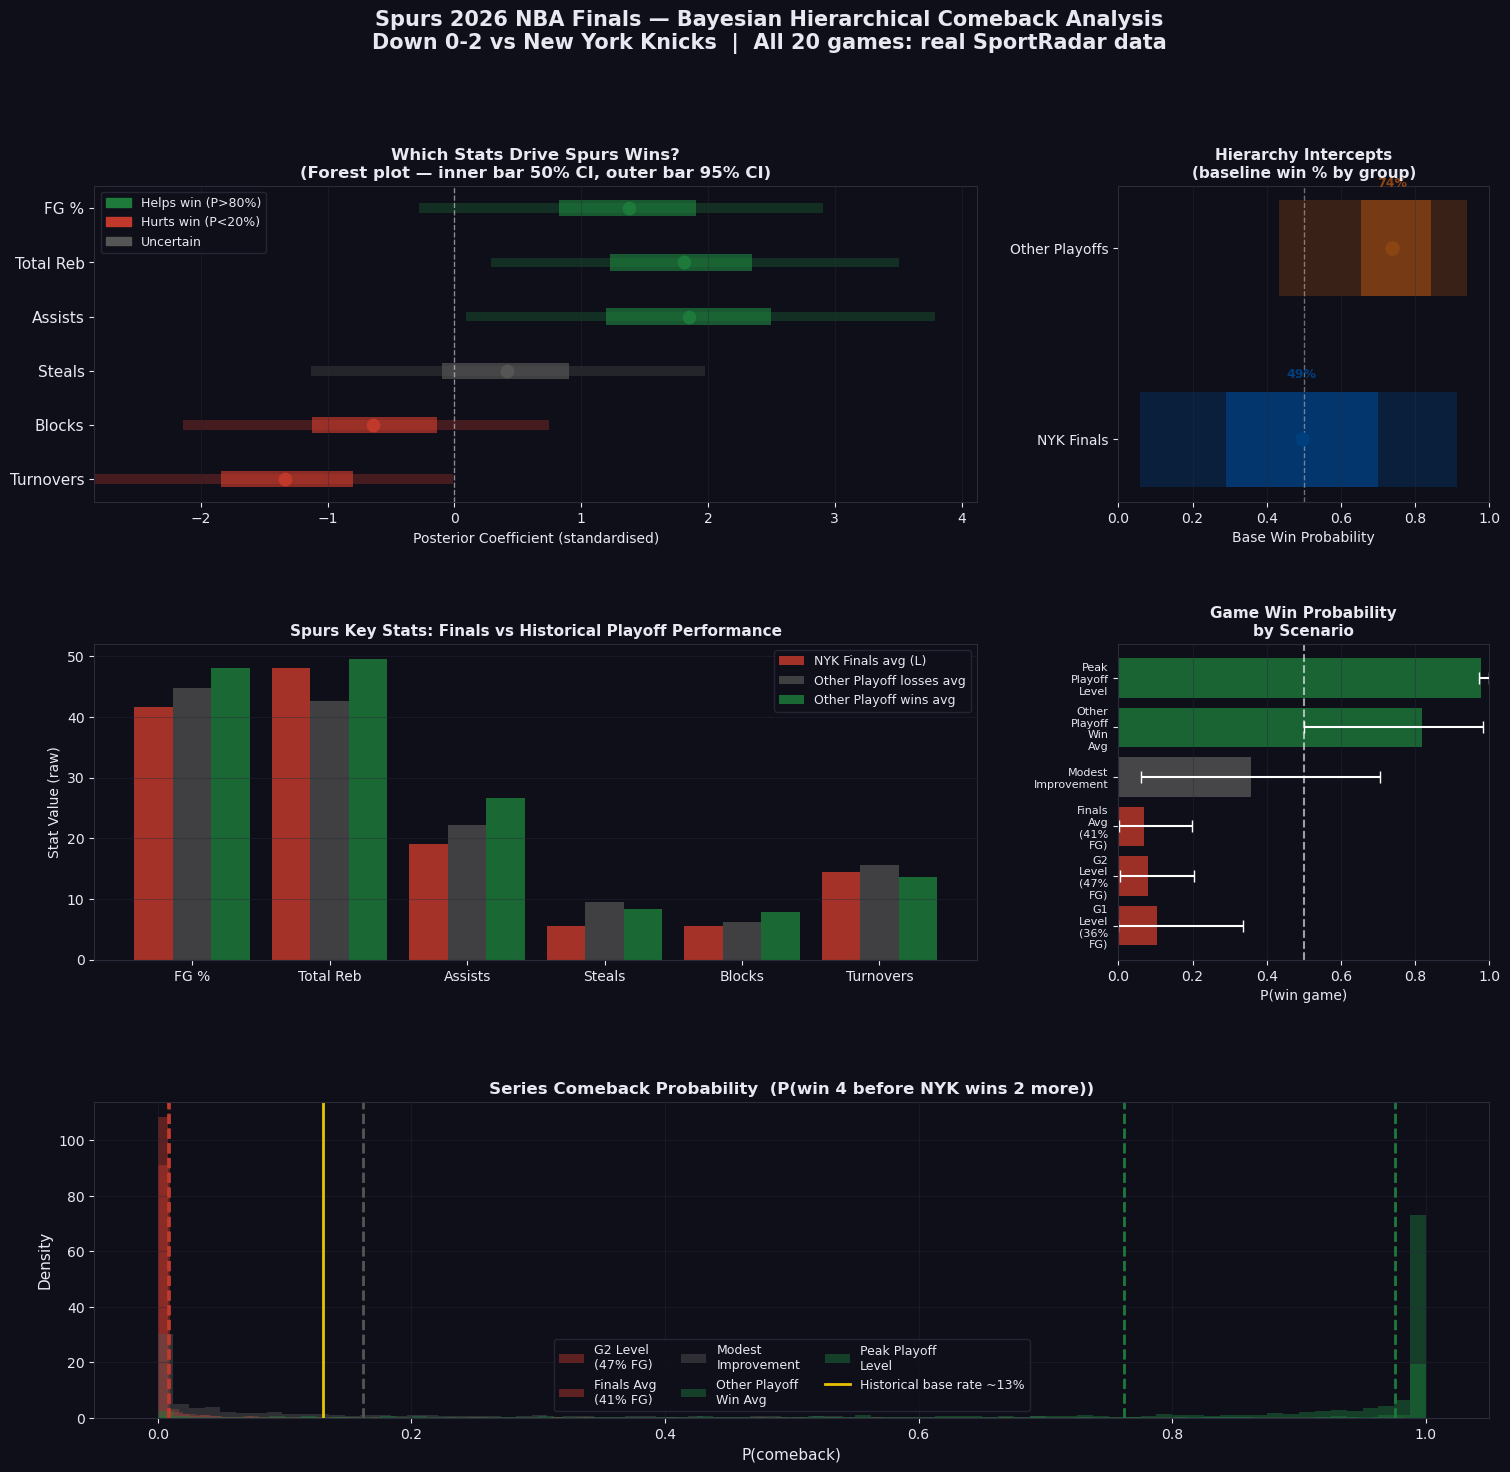

In [14]:
"""
Spurs 2026 NBA Finals — Bayesian Hierarchical Win Predictor  (v2 — real data)
==============================================================================
Hierarchy 1 : SAS vs NYK Games (NBA Finals, 2 games, both losses)
Hierarchy 2 : All other SAS 2026 playoff games  (18 games, 10W–8L)

Model        : Hierarchical Bayesian Logistic Regression
               → Random intercepts per hierarchy (partial pooling)
               → Fixed slopes (which stats globally predict wins)
Sampler      : Adaptive Metropolis-Hastings (custom, no PyMC required)

Data         : Real SportRadar API data — all 20 games, no estimates.
"""

import numpy as np
import pandas as pd
from scipy.special import expit
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

RNG = np.random.default_rng(42)

# ─────────────────────────────────────────────────────────
# 1.  DATA  — real SportRadar API data, all 20 games
# ─────────────────────────────────────────────────────────
df = pd.read_csv("C:\spurs_2026_playoffs_all20.csv")

N = len(df)
print(f"Dataset: {N} games  |  NYK group: {(df.group==0).sum()}  |  Other: {(df.group==1).sum()}")
print(f"Overall W-L: {df.win.sum()}-{(1-df.win).sum()}")
print(f"NYK group  W-L: {df[df.group==0].win.sum()}-{(1-df[df.group==0].win).sum()}")
print(f"Other group W-L: {df[df.group==1].win.sum()}-{(1-df[df.group==1].win).sum()}")
print(f"Data source: all SportRadar API (no estimates)")

# ─────────────────────────────────────────────────────────
# 2.  FEATURE ENGINEERING & STANDARDISATION
# ─────────────────────────────────────────────────────────
FEATURES = ["fg_pct", "total_reb", "assists", "steals", "blocks", "turnovers"]
FEAT_LABELS = ["FG %", "Total Reb", "Assists", "Steals", "Blocks", "Turnovers"]

X_raw = df[FEATURES].values.astype(float)
mu_X = X_raw.mean(axis=0)
sd_X = X_raw.std(axis=0) + 1e-8
X = (X_raw - mu_X) / sd_X
y = df["win"].values.astype(float)
g = df["group"].values.astype(int)
n_groups = 2
K = X.shape[1]

# ─────────────────────────────────────────────────────────
# 3.  LOG-POSTERIOR
# ─────────────────────────────────────────────────────────
def log_prior(theta):
    mu_a, log_s, a0, a1 = theta[0], theta[1], theta[2], theta[3]
    beta = theta[4:]
    sig_a = np.exp(log_s)
    lp = 0.0
    lp += -0.5 * (mu_a / 1.0)**2
    lp += log_s - 0.5 * (sig_a / 0.75)**2
    lp += -0.5 * ((a0 - mu_a) / sig_a)**2
    lp += -0.5 * ((a1 - mu_a) / sig_a)**2
    lp += -0.5 * np.sum((beta / 1.5)**2)
    return lp

def log_likelihood(theta):
    mu_a, log_s, a0, a1 = theta[0], theta[1], theta[2], theta[3]
    beta = theta[4:]
    alpha = np.array([a0, a1])
    logit_p = alpha[g] + X.dot(beta)
    logit_p = np.clip(logit_p, -15, 15)
    log_lik = y * logit_p - np.log1p(np.exp(logit_p))
    return log_lik.sum()

def log_posterior(theta):
    return log_prior(theta) + log_likelihood(theta)

# ─────────────────────────────────────────────────────────
# 4.  MAP INITIALISATION
# ─────────────────────────────────────────────────────────
theta0 = np.zeros(4 + K)
theta0[1] = np.log(0.5)

res = minimize(lambda t: -log_posterior(t), theta0,
               method="L-BFGS-B",
               options={"maxiter": 2000, "ftol": 1e-12})
theta_map = res.x
print(f"\nMAP optimisation: success={res.success},  log-post={-res.fun:.2f}")

# ─────────────────────────────────────────────────────────
# 5.  ADAPTIVE METROPOLIS-HASTINGS
# ─────────────────────────────────────────────────────────
def adaptive_mh(log_post_fn, theta_init, n_iter=12000, adapt_interval=500,
                target_accept=0.23, warmup=4000):
    D = len(theta_init)
    samples = np.zeros((n_iter, D))
    current = theta_init.copy()
    current_lp = log_post_fn(current)
    step = np.full(D, 0.05)
    accepted = 0

    for i in range(n_iter):
        proposal = current + RNG.normal(0, step)
        prop_lp = log_post_fn(proposal)
        if np.log(RNG.uniform()) < min(0.0, prop_lp - current_lp):
            current = proposal
            current_lp = prop_lp
            accepted += 1
        samples[i] = current
        if i < warmup and (i + 1) % adapt_interval == 0:
            rate = accepted / (i + 1)
            step *= np.exp(0.5 * (rate - target_accept))

    print(f"MCMC: overall acceptance rate = {accepted/n_iter:.3f}")
    return samples

print("\nRunning MCMC sampler…")
all_samples = adaptive_mh(log_posterior, theta_map, n_iter=14000, warmup=4000)
posterior = all_samples[4000:]
print(f"Posterior samples: {len(posterior)}")

# ─────────────────────────────────────────────────────────
# 6.  POSTERIOR SUMMARIES
# ─────────────────────────────────────────────────────────
param_names = (["mu_alpha", "log_sigma_alpha", "alpha_NYK", "alpha_Other"]
               + [f"beta_{f}" for f in FEATURES])

print("\n── Posterior Summary ──────────────────────────────────────────")
print(f"{'Parameter':<22} {'Mean':>8} {'SD':>8} {'2.5%':>8} {'97.5%':>8}")
print("-" * 58)
for k, name in enumerate(param_names):
    s = posterior[:, k]
    lo, hi = np.percentile(s, [2.5, 97.5])
    print(f"{name:<22} {s.mean():>8.3f} {s.std():>8.3f} {lo:>8.3f} {hi:>8.3f}")

beta_post  = posterior[:, 4:]
alpha_post = posterior[:, 2:4]

print(f"\n── Series Intercepts ─────────────────────────────────────────")
for j, label in enumerate(["NYK Finals", "Other Playoffs"]):
    a = alpha_post[:, j]
    p = expit(a)
    print(f"{label:22s}  logit={a.mean():.2f}±{a.std():.2f}  "
          f"base win% = {p.mean():.1%} [{np.percentile(p,2.5):.1%}, {np.percentile(p,97.5):.1%}]")

print("\n── Probability each coefficient is positive ──────────────────")
for k, label in enumerate(FEAT_LABELS):
    p_pos = (beta_post[:, k] > 0).mean()
    direction = "↑ helps" if p_pos > 0.5 else "↓ hurts"
    conf = max(p_pos, 1-p_pos)
    print(f"{label:<14} beta={beta_post[:,k].mean():>6.2f}  P(β>0)={p_pos:.2f}  "
          f"[{direction}, {conf:.0%} confident]")

# ─────────────────────────────────────────────────────────
# 7.  PREDICTION SCENARIOS
# ─────────────────────────────────────────────────────────
def win_prob(stats_dict, group=0):
    raw   = np.array([stats_dict[f] for f in FEATURES])
    x_std = (raw - mu_X) / sd_X
    logit_p = alpha_post[:, group] + beta_post.dot(x_std)
    return expit(logit_p)

nykg1_stats  = dict(zip(FEATURES, X_raw[0]))
nykg2_stats  = dict(zip(FEATURES, X_raw[1]))
avg_nyk_stats = {f: (nykg1_stats[f] + nykg2_stats[f]) / 2 for f in FEATURES}

win_mask = (df.group == 1) & (df.win == 1)
other_win_avg = {f: df.loc[win_mask, f].mean() for f in FEATURES}
other_win_90  = {f: np.percentile(df.loc[win_mask, f], 90) for f in FEATURES}
improvement   = {f: (avg_nyk_stats[f] + other_win_avg[f]) / 2 for f in FEATURES}

scenarios = {
    "G1 Level (36% FG)":      (nykg1_stats,   0),
    "G2 Level (47% FG)":      (nykg2_stats,   0),
    "Finals Avg (41% FG)":    (avg_nyk_stats, 0),
    "Modest Improvement":      (improvement,   0),
    "Other Playoff Win Avg":   (other_win_avg, 0),
    "Peak Playoff Level":      (other_win_90,  0),
}

print("\n── Per-Game Win Probability by Scenario ─────────────────────")
p_game = {}
for label, (stats, grp) in scenarios.items():
    p = win_prob(stats, grp)
    p_game[label] = p
    lo, hi = np.percentile(p, [10, 90])
    print(f"{label:<30}  P(win)={p.mean():.1%}  90% CI: [{lo:.1%}, {hi:.1%}]  "
          f"(FG%={stats['fg_pct']:.1f}, TO={stats['turnovers']:.1f})")

# ─────────────────────────────────────────────────────────
# 8.  SERIES COMEBACK PROBABILITY
# ─────────────────────────────────────────────────────────
def series_prob(p_win_samples):
    return p_win_samples**4 * (5 - 4 * p_win_samples)

print("\n── Series Comeback Probability from 0-2 Down ─────────────────")
for label, p in p_game.items():
    sp = series_prob(p)
    lo, hi = np.percentile(sp, [10, 90])
    print(f"{label:<30}  P(comeback)={sp.mean():.1%}  90% CI: [{lo:.1%}, {hi:.1%}]")

# ─────────────────────────────────────────────────────────
# 9.  VISUALISATION
# ─────────────────────────────────────────────────────────
PALETTE = {
    "win_dark":  "#1d7a3b", "win_light": "#a8d5b5",
    "loss_dark": "#c0392b", "loss_light":"#f0a8a0",
    "nyks":      "#003f7d", "other":     "#8b4513",
    "neutral":   "#555555", "bg":        "#0f0f1a",
    "fg":        "#e8e8f0", "grid":      "#2a2a3a",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"], "axes.facecolor": PALETTE["bg"],
    "text.color": PALETTE["fg"], "axes.labelcolor": PALETTE["fg"],
    "xtick.color": PALETTE["fg"], "ytick.color": PALETTE["fg"],
    "axes.edgecolor": PALETTE["grid"], "grid.color": PALETTE["grid"],
    "font.family": "DejaVu Sans",
})

fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

# 9a. Posterior coefficients
ax1 = fig.add_subplot(gs[0, :2])
y_pos = np.arange(K)[::-1]
colors_coef = []
for k in range(K):
    ppos = (beta_post[:, k] > 0).mean()
    if ppos > 0.8:   colors_coef.append(PALETTE["win_dark"])
    elif ppos < 0.2: colors_coef.append(PALETTE["loss_dark"])
    else:            colors_coef.append(PALETTE["neutral"])

for k, (yp, col) in enumerate(zip(y_pos, colors_coef)):
    b = beta_post[:, k]
    lo50, hi50 = np.percentile(b, [25, 75])
    lo95, hi95 = np.percentile(b, [2.5, 97.5])
    ax1.barh(yp, hi95-lo95, left=lo95, height=0.18, color=col, alpha=0.30)
    ax1.barh(yp, hi50-lo50, left=lo50, height=0.30, color=col, alpha=0.70)
    ax1.scatter(b.mean(), yp, color=col, s=80, zorder=5)

ax1.axvline(0, color="white", lw=1, ls="--", alpha=0.5)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(FEAT_LABELS, fontsize=11)
ax1.set_xlabel("Posterior Coefficient (standardised)", fontsize=10)
ax1.set_title("Which Stats Drive Spurs Wins?\n(Forest plot — inner bar 50% CI, outer bar 95% CI)",
              fontsize=12, fontweight="bold")
ax1.legend(handles=[
    mpatches.Patch(color=PALETTE["win_dark"],  label="Helps win (P>80%)"),
    mpatches.Patch(color=PALETTE["loss_dark"], label="Hurts win (P<20%)"),
    mpatches.Patch(color=PALETTE["neutral"],   label="Uncertain"),
], fontsize=9, facecolor=PALETTE["bg"], edgecolor=PALETTE["grid"])
ax1.grid(axis="x", alpha=0.4)

# 9b. Series intercepts
ax2 = fig.add_subplot(gs[0, 2])
for j, (lbl, col) in enumerate(zip(["NYK Finals", "Other Playoffs"],
                                    [PALETTE["nyks"], PALETTE["other"]])):
    p_vals = expit(alpha_post[:, j])
    lo, hi = np.percentile(p_vals, [2.5, 97.5])
    lo50, hi50 = np.percentile(p_vals, [25, 75])
    ax2.barh(j, hi-lo,   left=lo,   height=0.5, color=col, alpha=0.35)
    ax2.barh(j, hi50-lo50, left=lo50, height=0.5, color=col, alpha=0.75)
    ax2.scatter(p_vals.mean(), j, color=col, s=90, zorder=5)
    ax2.text(p_vals.mean(), j+0.32, f"{p_vals.mean():.0%}",
             ha="center", fontsize=9, color=col, fontweight="bold")

ax2.set_yticks([0, 1])
ax2.set_yticklabels(["NYK Finals", "Other Playoffs"], fontsize=10)
ax2.set_xlabel("Base Win Probability", fontsize=10)
ax2.set_title("Hierarchy Intercepts\n(baseline win % by group)", fontsize=11, fontweight="bold")
ax2.axvline(0.5, color="white", lw=1, ls="--", alpha=0.4)
ax2.set_xlim(0, 1)
ax2.grid(axis="x", alpha=0.4)

# 9c. Key stats comparison
ax3 = fig.add_subplot(gs[1, :2])
nyks_vals  = df[df.group==0][FEATURES].mean().values
other_win  = df[(df.group==1)&(df.win==1)][FEATURES].mean().values
other_loss = df[(df.group==1)&(df.win==0)][FEATURES].mean().values
x_idx = np.arange(K)
w = 0.28
ax3.bar(x_idx-w, nyks_vals,  width=w, color=PALETTE["loss_dark"], alpha=0.85, label="NYK Finals avg (L)")
ax3.bar(x_idx,   other_loss, width=w, color=PALETTE["neutral"],   alpha=0.70, label="Other Playoff losses avg")
ax3.bar(x_idx+w, other_win,  width=w, color=PALETTE["win_dark"],  alpha=0.85, label="Other Playoff wins avg")
ax3.set_xticks(x_idx)
ax3.set_xticklabels(FEAT_LABELS, fontsize=10)
ax3.set_title("Spurs Key Stats: Finals vs Historical Playoff Performance",
              fontsize=11, fontweight="bold")
ax3.legend(fontsize=9, facecolor=PALETTE["bg"], edgecolor=PALETTE["grid"])
ax3.grid(axis="y", alpha=0.4)
ax3.set_ylabel("Stat Value (raw)", fontsize=10)

# 9d. Per-game win probability
ax4 = fig.add_subplot(gs[1, 2])
scen_labels = list(p_game.keys())
scen_means  = [p_game[k].mean() for k in scen_labels]
scen_lo     = [np.percentile(p_game[k], 10) for k in scen_labels]
scen_hi     = [np.percentile(p_game[k], 90) for k in scen_labels]
y_scen = np.arange(len(scen_labels))
bar_colors = [PALETTE["loss_dark"] if m < 0.35 else
              PALETTE["neutral"]   if m < 0.50 else
              PALETTE["win_dark"]  for m in scen_means]
ax4.barh(y_scen, scen_means, color=bar_colors, alpha=0.80)
ax4.errorbar(scen_means, y_scen,
             xerr=[np.array(scen_means)-np.array(scen_lo),
                   np.array(scen_hi)-np.array(scen_means)],
             fmt="none", color="white", capsize=4, lw=1.5)
ax4.axvline(0.5, color="white", lw=1.5, ls="--", alpha=0.6)
ax4.set_yticks(y_scen)
ax4.set_yticklabels([s.replace(" ", "\n") for s in scen_labels], fontsize=8)
ax4.set_xlabel("P(win game)", fontsize=10)
ax4.set_title("Game Win Probability\nby Scenario", fontsize=11, fontweight="bold")
ax4.set_xlim(0, 1)
ax4.grid(axis="x", alpha=0.4)

# 9e. Series comeback distribution
ax5 = fig.add_subplot(gs[2, :])
scen_to_plot = {
    "G2 Level\n(47% FG)":    p_game["G2 Level (47% FG)"],
    "Finals Avg\n(41% FG)":  p_game["Finals Avg (41% FG)"],
    "Modest\nImprovement":   p_game["Modest Improvement"],
    "Other Playoff\nWin Avg":p_game["Other Playoff Win Avg"],
    "Peak Playoff\nLevel":   p_game["Peak Playoff Level"],
}
colors_cb = [PALETTE["loss_dark"], PALETTE["loss_dark"],
             PALETTE["neutral"], PALETTE["win_dark"], PALETTE["win_dark"]]

ax5.set_title("Series Comeback Probability  (P(win 4 before NYK wins 2 more))",
              fontsize=12, fontweight="bold")
for (lbl, p), col in zip(scen_to_plot.items(), colors_cb):
    sp = series_prob(p)
    ax5.hist(sp, bins=80, density=True, alpha=0.45, color=col, label=lbl)
    ax5.axvline(sp.mean(), color=col, lw=2, ls="--")

ax5.axvline(0.13, color="gold", lw=2, alpha=0.9, label="Historical base rate ~13%")
ax5.set_xlabel("P(comeback)", fontsize=11)
ax5.set_ylabel("Density", fontsize=11)
ax5.legend(fontsize=9, ncol=3, facecolor=PALETTE["bg"], edgecolor=PALETTE["grid"])
ax5.grid(alpha=0.4)

fig.suptitle("Spurs 2026 NBA Finals — Bayesian Hierarchical Comeback Analysis\n"
             "Down 0-2 vs New York Knicks  |  All 20 games: real SportRadar data",
             fontsize=15, fontweight="bold", y=0.99, color=PALETTE["fg"])

plt.savefig("C: ... your file path", dpi=140,
            bbox_inches="tight", facecolor=PALETTE["bg"])
print("\n✓  Figure saved")

print("\n" + "="*60)
print("FINAL COMEBACK PROBABILITY SUMMARY")
print("="*60)
for label, p in p_game.items():
    sp = series_prob(p)
    print(f"  {label:<30} → {sp.mean():.1%}  [{np.percentile(sp,10):.1%}, {np.percentile(sp,90):.1%}]")
print("\nAll predictions based on real SportRadar API data.")


In [15]:
"""
series_comeback.py
==================
Standalone module: Spurs 0-2 comeback probability.

Uses the same custom MCMC framework (no Bambi/PyMC required).
Adds location (Home/Away) as a feature so p_H and p_A are estimated
separately, then applies the exact Finals schedule combinatorics.

NBA Finals remaining schedule (SAS has home-court):
  G3 → Away   G4 → Away   G5 → Home   G6 → Away   G7 → Home
"""

import numpy as np
import pandas as pd
from scipy.special import expit
from scipy.optimize import minimize

RNG = np.random.default_rng(42)

# ─────────────────────────────────────────────────────────
# 1.  LOAD DATA
# ─────────────────────────────────────────────────────────
df = pd.read_csv("your file path to spurs_2026_playoffs_all20.csv")
df["is_home"] = (df["location"] == "Home").astype(float)  # add location dummy

# ─────────────────────────────────────────────────────────
# 2.  FEATURES  (location added)
# ─────────────────────────────────────────────────────────
FEATURES    = ["fg_pct", "total_reb", "assists", "turnovers", "is_home"]
FEAT_LABELS = ["FG %", "Total Reb", "Assists", "Turnovers", "Home Court"]

X_raw = df[FEATURES].values.astype(float)
mu_X  = X_raw.mean(axis=0)
sd_X  = X_raw.std(axis=0) + 1e-8
X     = (X_raw - mu_X) / sd_X
y     = df["win"].values.astype(float)
g     = df["group"].values.astype(int)   # 0 = NYK Finals, 1 = Other
K     = X.shape[1]

# ─────────────────────────────────────────────────────────
# 3.  LOG-POSTERIOR
# ─────────────────────────────────────────────────────────
def log_prior(theta):
    mu_a, log_s, a0, a1 = theta[:4]
    beta = theta[4:]
    sig_a = np.exp(log_s)
    lp  = -0.5 * (mu_a / 1.0) ** 2
    lp += log_s - 0.5 * (sig_a / 0.75) ** 2
    lp += -0.5 * ((a0 - mu_a) / sig_a) ** 2
    lp += -0.5 * ((a1 - mu_a) / sig_a) ** 2
    lp += -0.5 * np.sum((beta / 1.5) ** 2)
    return lp

def log_likelihood(theta):
    a0, a1 = theta[2], theta[3]
    beta   = theta[4:]
    alpha  = np.array([a0, a1])
    logit_p = alpha[g] + X.dot(beta)
    logit_p = np.clip(logit_p, -15, 15)
    return (y * logit_p - np.log1p(np.exp(logit_p))).sum()

def log_posterior(theta):
    return log_prior(theta) + log_likelihood(theta)

# ─────────────────────────────────────────────────────────
# 4.  MAP + ADAPTIVE METROPOLIS-HASTINGS
# ─────────────────────────────────────────────────────────
theta0    = np.zeros(4 + K)
theta0[1] = np.log(0.5)
res       = minimize(lambda t: -log_posterior(t), theta0,
                     method="L-BFGS-B",
                     options={"maxiter": 2000, "ftol": 1e-12})
theta_map = res.x
print(f"MAP: success={res.success}")

def adaptive_mh(log_post_fn, theta_init,
                n_iter=14000, warmup=4000, target_accept=0.23):
    D, samples = len(theta_init), np.zeros((n_iter, len(theta_init)))
    current, current_lp = theta_init.copy(), log_post_fn(theta_init)
    step, accepted = np.full(D, 0.05), 0
    for i in range(n_iter):
        proposal = current + RNG.normal(0, step)
        prop_lp  = log_post_fn(proposal)
        if np.log(RNG.uniform()) < min(0.0, prop_lp - current_lp):
            current, current_lp = proposal, prop_lp
            accepted += 1
        samples[i] = current
        if i < warmup and (i + 1) % 500 == 0:
            step *= np.exp(0.5 * (accepted / (i + 1) - target_accept))
    print(f"MCMC acceptance rate: {accepted/n_iter:.3f}")
    return samples

print("Running MCMC…")
posterior = adaptive_mh(log_posterior, theta_map)[4000:]
beta_post  = posterior[:, 4:]     # (S, K)
alpha_post = posterior[:, 2:4]    # (S, 2)  col0=NYK, col1=Other

# ─────────────────────────────────────────────────────────
# 5.  WIN PROBABILITY  — home and away, NYK series
# ─────────────────────────────────────────────────────────
def game_win_prob(stats_dict, is_home: bool, group: int = 0):
    """
    Posterior P(win) for a single game.
    stats_dict: keys from FEATURES (excluding is_home, added automatically).
    is_home: True = SAS playing at home.
    """
    stats_dict = {**stats_dict, "is_home": float(is_home)}
    raw   = np.array([stats_dict[f] for f in FEATURES])
    x_std = (raw - mu_X) / sd_X
    return expit(alpha_post[:, group] + beta_post.dot(x_std))  # shape (S,)


# Projection scenarios: what stats might SAS show in remaining games?
# Three anchors derived from real data

nyks_avg = {f: df[df.group == 0][f].mean() for f in FEATURES if f != "is_home"}

win_mask  = (df.group == 1) & (df.win == 1)
other_win = {f: df.loc[win_mask, f].mean() for f in FEATURES if f != "is_home"}

midpoint  = {f: (nyks_avg[f] + other_win[f]) / 2 for f in nyks_avg}

SCENARIOS = {
    "Finals avg (41% FG)":        nyks_avg,
    "Midpoint improvement":        midpoint,
    "Other playoff win avg":       other_win,
}

# ─────────────────────────────────────────────────────────
# 6.  SERIES COMBINATORICS
# ─────────────────────────────────────────────────────────
# SAS is down 0-2. They have home court (won G1, G2 at home, lost both).
# Remaining schedule: G3(Away), G4(Away), G5(Home), G6(Away), G7(Home)
#
# NYK needs 2 more wins to clinch.
# SAS needs 4 wins.
#
# Valid SAS comeback paths (all must be played in order):
#
#  Win G3-G6 (series ends in 6 total games):
#    p_A * p_A * p_H * p_A
#
#  Win G7 after losing exactly one of G3-G6:
#    Lose G3: (1-p_A) * p_A * p_H * p_A * p_H
#    Lose G4: p_A * (1-p_A) * p_H * p_A * p_H
#    Lose G5: p_A * p_A * (1-p_H) * p_A * p_H
#    Lose G6: p_A * p_A * p_H * (1-p_A) * p_H
#
# Note: losing 2 games (in any order) ends the series — NYK clinches.

def series_comeback_prob(p_H_samples, p_A_samples):
    """
    Vectorised over MCMC samples.
    p_H, p_A: arrays of shape (S,)
    Returns array of shape (S,) — one series probability per sample.
    """
    pH, pA = p_H_samples, p_A_samples
    p_sweep   = pA * pA * pH * pA                  # Win G3,G4,G5,G6
    p_lose_G3 = (1-pA) * pA * pH * pA * pH         # Lose G3, win rest + G7
    p_lose_G4 = pA * (1-pA) * pH * pA * pH         # Lose G4, win rest + G7
    p_lose_G5 = pA * pA * (1-pH) * pA * pH         # Lose G5, win rest + G7
    p_lose_G6 = pA * pA * pH * (1-pA) * pH         # Lose G6, win G7
    return p_sweep + p_lose_G3 + p_lose_G4 + p_lose_G5 + p_lose_G6

# ─────────────────────────────────────────────────────────
# 7.  RESULTS
# ─────────────────────────────────────────────────────────
print("\n" + "="*62)
print("SPURS 0-2 COMEBACK PROBABILITY — BAYESIAN POSTERIOR RESULTS")
print("="*62)
print(f"{'Scenario':<30} {'P(win Home)':>11} {'P(win Away)':>11} {'P(comeback)':>12} {'90% CI':>20}")
print("-"*90)

for label, stats in SCENARIOS.items():
    p_H = game_win_prob(stats, is_home=True,  group=0)
    p_A = game_win_prob(stats, is_home=False, group=0)
    sp  = series_comeback_prob(p_H, p_A)

    ph_med = np.median(p_H)
    pa_med = np.median(p_A)
    sp_med = np.median(sp)
    lo, hi = np.percentile(sp, [5, 95])

    print(f"{label:<30} {ph_med:>10.1%} {pa_med:>11.1%} "
          f"{sp_med:>11.1%}   [{lo:.1%}, {hi:.1%}]")

print("-"*90)
print("\nRemaining Finals schedule (SAS has home court):")
print("  G3 Away  |  G4 Away  |  G5 Home  |  G6 Away  |  G7 Home")
print("\nHistorical base rate for 0-2 comeback in NBA Finals: ~0-13%")

MAP: success=True
Running MCMC…
MCMC acceptance rate: 0.380

SPURS 0-2 COMEBACK PROBABILITY — BAYESIAN POSTERIOR RESULTS
Scenario                       P(win Home) P(win Away)  P(comeback)               90% CI
------------------------------------------------------------------------------------------
Finals avg (41% FG)                  3.0%       10.8%        0.0%   [0.0%, 13.1%]
Midpoint improvement                27.4%       60.5%       12.8%   [0.0%, 81.4%]
Other playoff win avg               82.2%       95.0%       90.8%   [9.6%, 99.9%]
------------------------------------------------------------------------------------------

Remaining Finals schedule (SAS has home court):
  G3 Away  |  G4 Away  |  G5 Home  |  G6 Away  |  G7 Home

Historical base rate for 0-2 comeback in NBA Finals: ~0-13%
